In [2]:
import pandas as pd
import numpy as np
import json 
import requests 

In [3]:
PIB_per_capita = 'NY.GDP.PCAP.CD'


In [4]:
#Construir la consulta al banco mundial
url = 'http://api.worldbank.org/v2/country/all/indicator/{}'
params = {
    'format': 'json',
    'date': '2010:2022',
    'per_page': '30000'
}

In [5]:
respuesta = requests.get(url.format('NY.GDP.PCAP.CD'), params=params)

In [6]:
respuesta.json

<bound method Response.json of <Response [200]>>

In [7]:
respuesta.json()

[{'page': 1,
  'pages': 1,
  'per_page': 30000,
  'total': 3458,
  'sourceid': '2',
  'lastupdated': '2025-07-01'},
 [{'indicator': {'id': 'NY.GDP.PCAP.CD',
    'value': 'GDP per capita (current US$)'},
   'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
   'countryiso3code': 'AFE',
   'date': '2022',
   'value': 1628.31894446307,
   'unit': '',
   'obs_status': '',
   'decimal': 1},
  {'indicator': {'id': 'NY.GDP.PCAP.CD',
    'value': 'GDP per capita (current US$)'},
   'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
   'countryiso3code': 'AFE',
   'date': '2021',
   'value': 1522.3933455926,
   'unit': '',
   'obs_status': '',
   'decimal': 1},
  {'indicator': {'id': 'NY.GDP.PCAP.CD',
    'value': 'GDP per capita (current US$)'},
   'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
   'countryiso3code': 'AFE',
   'date': '2020',
   'value': 1344.10320999294,
   'unit': '',
   'obs_status': '',
   'decimal': 1},
  {'indicator': {'id': '

In [8]:
PIB = respuesta.json()

In [9]:
print(len(PIB))

2


In [10]:
PIB[0]

{'page': 1,
 'pages': 1,
 'per_page': 30000,
 'total': 3458,
 'sourceid': '2',
 'lastupdated': '2025-07-01'}

In [11]:
PIB[1]

[{'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2022',
  'value': 1628.31894446307,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2021',
  'value': 1522.3933455926,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2020',
  'value': 1344.10320999294,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3c

In [12]:
Indicadores = PIB[1]

In [13]:
df = pd.DataFrame(Indicadores)

In [14]:
df.columns

Index(['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit',
       'obs_status', 'decimal'],
      dtype='object')

In [15]:
df = df[["country", "date", "value"]]

In [16]:
df

,country,date,value
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2022,1628.318944
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2021,1522.393346
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2020,1344.103210
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2019,1493.817938
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2018,1538.901679
...,...,...,...
3453,"{'id': 'ZW', 'value': 'Zimbabwe'}",2014,1372.214746
3454,"{'id': 'ZW', 'value': 'Zimbabwe'}",2013,1362.299529
3455,"{'id': 'ZW', 'value': 'Zimbabwe'}",2012,1238.594795
3456,"{'id': 'ZW', 'value': 'Zimbabwe'}",2011,1037.246137


In [17]:
df.head()

,country,date,value
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2022,1628.318944
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2021,1522.393346
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2020,1344.103210
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2019,1493.817938
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2018,1538.901679


In [18]:
df.describe()

,value
count,3369.000000
mean,16912.003647
std,25331.313163
min,210.008140
25%,2082.629890
50%,6517.954322
75%,20818.614609
max,226052.001905


In [19]:
df.size, df.shape

(10374, (3458, 3))

In [20]:
df["country_name"] = 0

In [21]:
df.loc[0]["country"]["value"]

'Africa Eastern and Southern'

In [22]:
df["country_name"] = df["country"].apply(lambda fila: fila["value"])

In [23]:
df

,country,date,value,country_name
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2022,1628.318944,Africa Eastern and Southern
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2021,1522.393346,Africa Eastern and Southern
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2020,1344.103210,Africa Eastern and Southern
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2019,1493.817938,Africa Eastern and Southern
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2018,1538.901679,Africa Eastern and Southern
...,...,...,...,...
3453,"{'id': 'ZW', 'value': 'Zimbabwe'}",2014,1372.214746,Zimbabwe
3454,"{'id': 'ZW', 'value': 'Zimbabwe'}",2013,1362.299529,Zimbabwe
3455,"{'id': 'ZW', 'value': 'Zimbabwe'}",2012,1238.594795,Zimbabwe
3456,"{'id': 'ZW', 'value': 'Zimbabwe'}",2011,1037.246137,Zimbabwe


In [24]:
df[df["country_name"] == "Ecuador"].describe()

,value
count,13.000000
mean,5884.601967
std,562.478788
min,4520.309590
25%,5634.083932
50%,6061.323502
75%,6233.322448
max,6515.585284


In [25]:
df[df["country_name"] == "Argentina"]

,country,date,value,country_name
728,"{'id': 'AR', 'value': 'Argentina'}",2022,13935.681111,Argentina
729,"{'id': 'AR', 'value': 'Argentina'}",2021,10738.017922,Argentina
730,"{'id': 'AR', 'value': 'Argentina'}",2020,8535.599380,Argentina
731,"{'id': 'AR', 'value': 'Argentina'}",2019,9955.974787,Argentina
732,"{'id': 'AR', 'value': 'Argentina'}",2018,11752.799892,Argentina
733,"{'id': 'AR', 'value': 'Argentina'}",2017,14532.500931,Argentina
734,"{'id': 'AR', 'value': 'Argentina'}",2016,12699.962314,Argentina
735,"{'id': 'AR', 'value': 'Argentina'}",2015,13679.626498,Argentina
736,"{'id': 'AR', 'value': 'Argentina'}",2014,12233.144412,Argentina
737,"{'id': 'AR', 'value': 'Argentina'}",2013,12963.675773,Argentina


In [26]:
paises = ["Ecuador", "Peru", "Japan"]

In [27]:
df[df["country_name"].isin(paises)]

,country,date,value,country_name
1378,"{'id': 'EC', 'value': 'Ecuador'}",2022,6515.585284,Ecuador
1379,"{'id': 'EC', 'value': 'Ecuador'}",2021,6061.323502,Ecuador
1380,"{'id': 'EC', 'value': 'Ecuador'}",2020,5463.645153,Ecuador
1381,"{'id': 'EC', 'value': 'Ecuador'}",2019,6205.057652,Ecuador
1382,"{'id': 'EC', 'value': 'Ecuador'}",2018,6303.918867,Ecuador
1383,"{'id': 'EC', 'value': 'Ecuador'}",2017,6233.322448,Ecuador
1384,"{'id': 'EC', 'value': 'Ecuador'}",2016,5917.637713,Ecuador
1385,"{'id': 'EC', 'value': 'Ecuador'}",2015,5976.159681,Ecuador
1386,"{'id': 'EC', 'value': 'Ecuador'}",2014,6405.799793,Ecuador
1387,"{'id': 'EC', 'value': 'Ecuador'}",2013,6109.290315,Ecuador


In [28]:
df[(df["date"] == "2020") & (df["country_name"] == "Ecuador")]

,country,date,value,country_name
1380,"{'id': 'EC', 'value': 'Ecuador'}",2020,5463.645153,Ecuador


In [29]:
PIB_EC = ["2021", "2022"]

In [30]:
df[(df["date"].isin(PIB_EC)) & (df["country_name"] == "Ecuador")]["value"].mean()

np.float64(6288.454393000235)

In [31]:
df[df["value"] == df["value"].max()]["country_name"]

2327    Monaco
Name: country_name, dtype: object

In [32]:
df[df["value"]> 20000]["country_name"].unique()

array(['Euro area', 'Europe & Central Asia', 'European Union',
       'High income', 'North America', 'OECD members',
       'Post-demographic dividend', 'Andorra', 'Antigua and Barbuda',
       'Aruba', 'Australia', 'Austria', 'Bahamas, The', 'Bahrain',
       'Barbados', 'Belgium', 'Bermuda', 'Brunei Darussalam', 'Canada',
       'Cayman Islands', 'Channel Islands', 'Curacao', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland',
       'France', 'French Polynesia', 'Germany', 'Greece', 'Greenland',
       'Guam', 'Hong Kong SAR, China', 'Iceland', 'Ireland',
       'Isle of Man', 'Israel', 'Italy', 'Japan', 'Korea, Rep.', 'Kuwait',
       'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg',
       'Macao SAR, China', 'Malta', 'Monaco', 'Netherlands',
       'New Caledonia', 'New Zealand', 'Northern Mariana Islands',
       'Norway', 'Oman', 'Portugal', 'Puerto Rico (US)', 'Qatar',
       'San Marino', 'Saudi Arabia', 'Singapore',
       'Sint Maarten (Dutch 

In [33]:
df

,country,date,value,country_name
0,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2022,1628.318944,Africa Eastern and Southern
1,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2021,1522.393346,Africa Eastern and Southern
2,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2020,1344.103210,Africa Eastern and Southern
3,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2019,1493.817938,Africa Eastern and Southern
4,"{'id': 'ZH', 'value': 'Africa Eastern and Sout...",2018,1538.901679,Africa Eastern and Southern
...,...,...,...,...
3453,"{'id': 'ZW', 'value': 'Zimbabwe'}",2014,1372.214746,Zimbabwe
3454,"{'id': 'ZW', 'value': 'Zimbabwe'}",2013,1362.299529,Zimbabwe
3455,"{'id': 'ZW', 'value': 'Zimbabwe'}",2012,1238.594795,Zimbabwe
3456,"{'id': 'ZW', 'value': 'Zimbabwe'}",2011,1037.246137,Zimbabwe


In [34]:
df.sort_values("value", ascending=False).head(7)["country_name"].unique().tolist()

['Monaco', 'Liechtenstein']

In [35]:
South_america = ["Argentina", "Colombia", "Brazil", "Peru", "Ecuador", "Chile", "Paraguay", "Uruguay", "Venezuela", "Bolivia"]

In [36]:
df[df["country_name"].isin(South_america)].sort_values("value", ascending=False).head()["country_name"].unique().tolist()

['Uruguay']

In [37]:
df.groupby("country_name")["value"].max().sort_values(ascending=False).head()

country_name
Monaco           226052.001905
Liechtenstein    201944.830335
Luxembourg       134965.815442
Bermuda          121613.939984
Norway           109269.520580
Name: value, dtype: float64

In [38]:
sa_df = df[df["country_name"].isin(South_america)]

In [39]:
sa_df

,country,date,value,country_name
728,"{'id': 'AR', 'value': 'Argentina'}",2022,13935.681111,Argentina
729,"{'id': 'AR', 'value': 'Argentina'}",2021,10738.017922,Argentina
730,"{'id': 'AR', 'value': 'Argentina'}",2020,8535.599380,Argentina
731,"{'id': 'AR', 'value': 'Argentina'}",2019,9955.974787,Argentina
732,"{'id': 'AR', 'value': 'Argentina'}",2018,11752.799892,Argentina
...,...,...,...,...
3336,"{'id': 'UY', 'value': 'Uruguay'}",2014,18322.427677,Uruguay
3337,"{'id': 'UY', 'value': 'Uruguay'}",2013,18335.259477,Uruguay
3338,"{'id': 'UY', 'value': 'Uruguay'}",2012,16259.594081,Uruguay
3339,"{'id': 'UY', 'value': 'Uruguay'}",2011,15132.267573,Uruguay


In [40]:
sa_df.groupby("country_name")["value"].mean().sort_values(ascending=False)

country_name
Uruguay      17387.273689
Chile        14570.887597
Argentina    12072.393462
Brazil       10197.466472
Colombia      6814.950483
Peru          6490.565991
Paraguay      5901.607612
Ecuador       5884.601967
Bolivia       3015.683805
Name: value, dtype: float64

In [41]:
sa_df.groupby("country_name").agg({"value":["min","mean","max"]})

value                            
                       min          mean           max
country_name                                          
Argentina      8535.599380  12072.393462  14532.500931
Bolivia        1929.783731   3015.683805   3643.928270
Brazil         7074.193783  10197.466472  13396.624356
Chile         12632.870472  14570.887597  16206.832549
Colombia       5339.687114   6814.950483   8279.102556
Ecuador        4520.309590   5884.601967   6515.585284
Paraguay       4750.962737   5901.607612   6652.254789
Peru           5072.114940   6490.565991   7350.630343
Uruguay       12641.057685  17387.273689  20818.614609

In [42]:
import matplotlib.pyplot as plt

In [43]:
import seaborn as sns

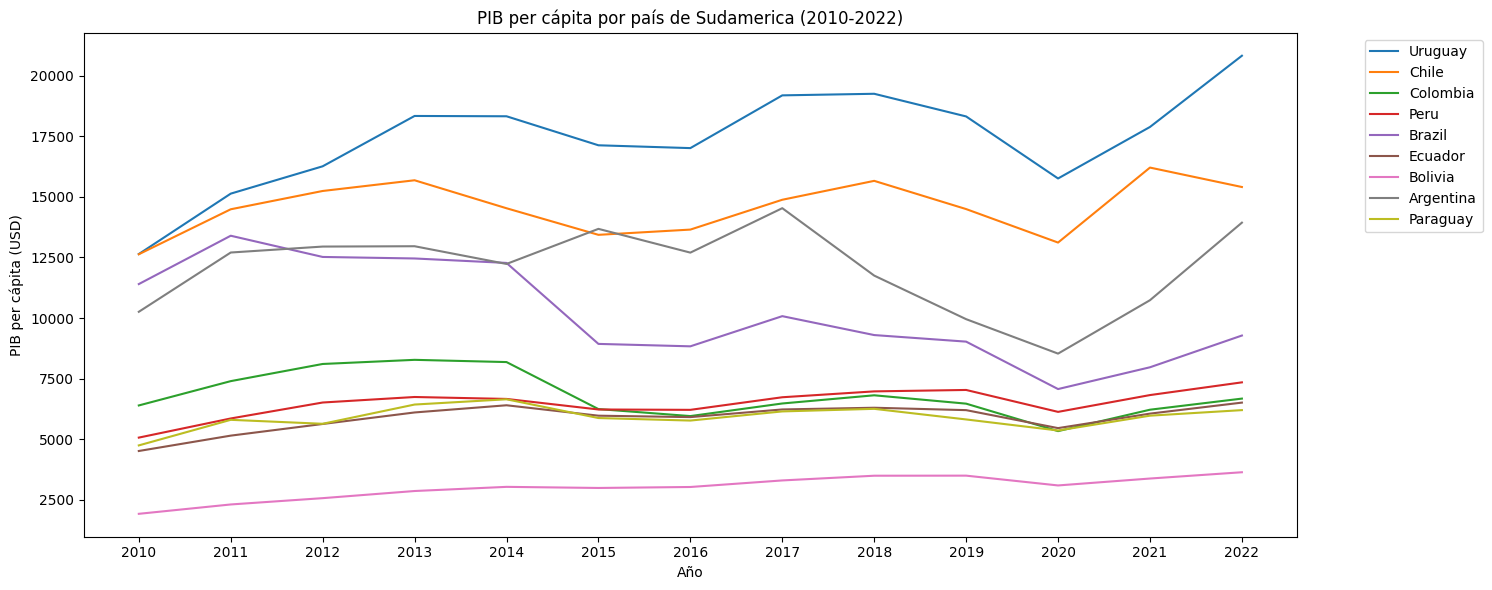

In [44]:

#sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
sns.lineplot(data = sa_df.sort_values("date", ascending=True), x='date', y='value', hue='country_name')
plt.title('PIB per cápita por país de Sudamerica (2010‑2022)')
plt.ylabel('PIB per cápita (USD)')
plt.xlabel('Año')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

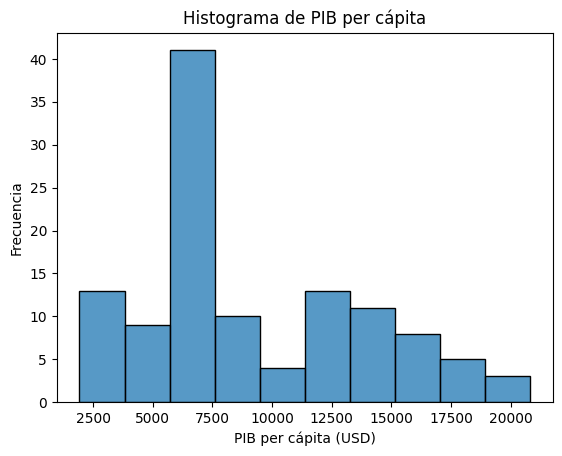

In [46]:
sns.histplot(data=sa_df, x="value", bins=10)
plt.title("Histograma de PIB per cápita")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Frecuencia")
plt.show()